# Exercise 2 – Lactic Acid Inhibition of *Streptococcus cremoris*


In [192]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# -- Matplotlib style --
plt.rcParams.update({'figure.dpi': 120, 'font.size': 12})


## Part (a) – Relative growth rate vs undissociated acid concentration P

### Theory
Lactic acid is a weak acid that partially dissociates in solution:
$$\text{HA} \rightleftharpoons \text{H}^+ + \text{A}^-$$

The Henderson–Hasselbalch equation gives the fraction of acid that is undissociated:
$$f_{\text{HA}} = \frac{1}{1 + 10^{\text{pH} - \text{pK}_a}}$$

The undissociated acid concentration (in mM) is therefore:
$$P = f_{\text{HA}} \times \frac{p_{\text{total}}}{M_w} \times 1000$$

where $p_{\text{total}}$ is the total lactic acid concentration in g/L and $M_w = 90.08$ g/mol.

The experiment was conducted at **pH = 6.3**, pKₐ = 3.88.

In [193]:
#Calculations with the theory and equations explained in the theory
p_total_gL = np.array([0.0, 12.0, 39.0, 55.0])   # g/L
mu_data    = np.array([0.90, 0.68, 0.52, 0.13])   # h⁻¹


pKa  = 3.88
Mw   = 90.08   # g/mol, molar mass of lactic acid


f_HA = 1.0 / (1.0 + 10**(pH - pKa))
print(f"Fraction undissociated (f_HA) at pH {pH}: {f_HA:.6f}")


P_mM = f_HA * (p_total_gL / Mw) * 1000.0
print("\nP_total (g/L) → P undissociated (mM):")
for pt, P in zip(p_total_gL, P_mM):
    print(f"  {pt:5.1f} g/L  →  {P:.4f} mM")


mu0     = mu_data[0]        # µ(P=0) = µmax under substrate saturation
mu_rel  = mu_data / mu0

print(f"\nµ(P=0) = µmax = {mu0} h⁻¹")

Fraction undissociated (f_HA) at pH 6.3: 0.003787

P_total (g/L) → P undissociated (mM):
    0.0 g/L  →  0.0000 mM
   12.0 g/L  →  0.5046 mM
   39.0 g/L  →  1.6398 mM
   55.0 g/L  →  2.3125 mM

µ(P=0) = µmax = 0.9 h⁻¹


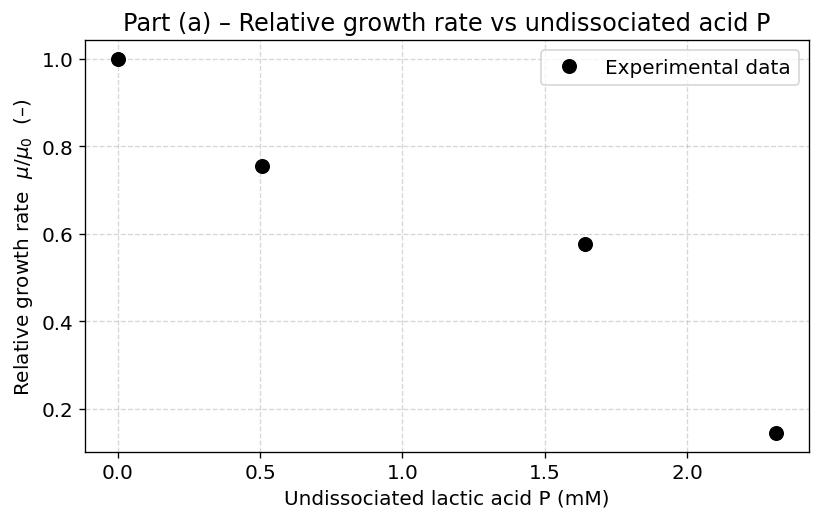

In [194]:
#  Plotting of µ_rel vs P 
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(P_mM, mu_rel, 'ko', markersize=8, label='Experimental data')
ax.set_xlabel('Undissociated lactic acid P (mM)')
ax.set_ylabel(r'Relative growth rate  $\mu / \mu_0$  (–)')
ax.set_title('Part (a) – Relative growth rate vs undissociated acid P')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('part_a_mu_rel_vs_P.png')
plt.show()

## Part (b) – Model 1: finding K_I 

### Proving that µ(P=0) = µ_max
The data are collected under substrate saturation, so by definition S ≫ K_S, meaning:
$$\frac{S}{K_S + S} \approx 1$$
The growth equation therefore reduces to:
$$\mu = \mu_{\max} \cdot 1 \cdot \frac{1}{1 + P/K_I} \xrightarrow{P \to 0} \mu_{\max}$$

### Model 1: equation
Under substrate saturation the model becomes:
$$\mu = \frac{\mu_{\max}}{1 + P/K_I}$$

Rearranging to a linear form suitable for the plot will be:
$$\frac{1}{\mu} = \frac{1}{\mu_{\max}} + \frac{1}{\mu_{\max} K_I} \cdot P$$

Plotting $1/\mu$ vs $P$ gives a straight line with: intercept = $1/\mu_{\max}$
 and slope = $1/(\mu_{\max} K_I)$  →  $K_I = 1 / (\text{slope} \times \mu_{\max})$

In [195]:
from scipy.optimize import curve_fit


# µ = µ_max / (1 + P/KI)
def model1(P, KI):
    return mu0 / (1.0 + P / KI)

popt, _ = curve_fit(model1, P_mM, mu_data, p0=[1.0])
KI_b = popt[0]
mu_max_b = mu0   # fixé

print(f"K_I (Model 1) = {KI_b:.4f} mM")
print(f"µ_max (fixé)  = {mu_max_b:.4f} h⁻¹")

#Predictions for the plot
P_fit         = np.linspace(0, max(P_mM) * 1.05, 300)
mu_pred1_data = model1(P_mM, KI_b)
mu_model1     = model1(P_fit, KI_b)
mu_rel_model1 = mu_model1 / mu0

K_I (Model 1) = 1.2311 mM
µ_max (fixé)  = 0.9000 h⁻¹


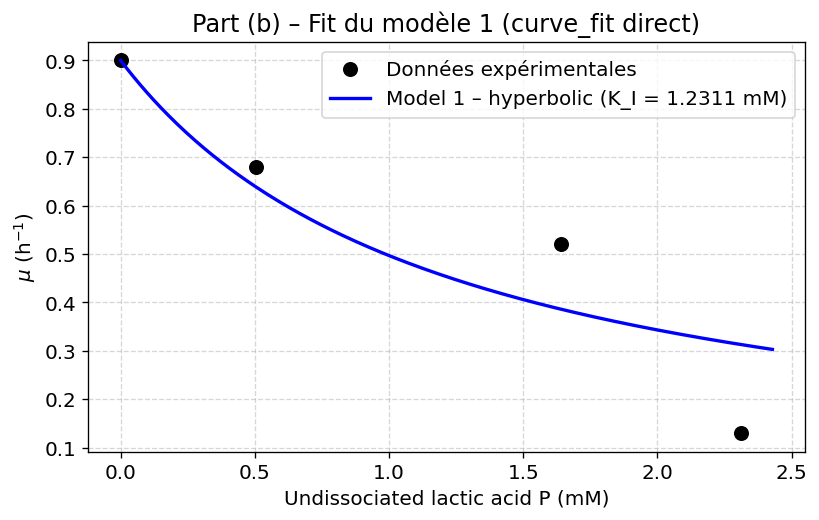

In [196]:
 # ── Verification plot of Model 1 ──────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(P_mM, mu_data, 'ko', markersize=8, label='Données expérimentales')
ax.plot(P_fit, mu_model1, 'b-', lw=2,
        label=f'Model 1 – hyperbolic (K_I = {KI_b:.4f} mM)')
ax.set_xlabel('Undissociated lactic acid P (mM)')
ax.set_ylabel(r'$\mu$ (h$^{-1}$)')
ax.set_title('Part (b) – Fit du modèle 1 (curve_fit direct)')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('part_b_model1_fit.png')
plt.show()

## Part (c) – Model 2: linear inhibition term

### Model 2 equation
Under substrate saturation:
$$\mu = \mu_{\max} \left(1 - \frac{P}{P_{\max}}\right)$$

The  parameter to estimate is P_max (the concentration of undissociated acid at which growth stops completely).  
Re-written in relative terms:
$$\frac{\mu}{\mu_{\max}} = 1 - \frac{P}{P_{\max}}$$

This is a straight line in µ vs P.

### Model comparison 
We use the Root Mean Square Error  on the original µ values:
$$\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(\mu_i^{\text{data}} - \mu_i^{\text{model}})^2}$$

and the coefficient of determination R²:
$$R^2 = 1 - \frac{\sum(\mu_i^{\text{data}} - \mu_i^{\text{model}})^2}{\sum(\mu_i^{\text{data}} - \bar{\mu})^2}$$

In [197]:
# Model 2: linear fit  
# Fit: mu vs P is linear 
# slope2 = -µ_max / P_max,  intercept2 = µ_max
coeffs2 = np.polyfit(P_mM, mu_data, 1)
slope2, intercept2 = coeffs2

mu_max_c = intercept2               
P_max_c  = -mu_max_c / slope2       # P at which µ = 0

print(f"Model 2 – linear fit on µ vs P:")
print(f"  slope     = {slope2:.6f} h⁻¹/mM")
print(f"  intercept = {intercept2:.4f} h⁻¹  (= µ_max estimate)")
print(f"  P_max     = {P_max_c:.4f} mM")

#  Model 2 (predictions) 
mu_model2     = mu_max_c * (1.0 - P_fit / P_max_c)
mu_rel_model2 = mu_model2 / mu_max_c
mu_pred2_data = np.polyval(coeffs2, P_mM)

# R² and RMSE 
def r2_rmse(y_data, y_pred):
    SS_res = np.sum((y_data - y_pred)**2)
    SS_tot = np.sum((y_data - np.mean(y_data))**2)
    r2   = 1.0 - SS_res / SS_tot
    rmse = np.sqrt(np.mean((y_data - y_pred)**2))
    return r2, rmse

r2_m1, rmse_m1 = r2_rmse(mu_data, mu_pred1_data)
r2_m2, rmse_m2 = r2_rmse(mu_data, mu_pred2_data)

print(f"\nModel 1 (hyperbolic):  R² = {r2_m1:.5f},  RMSE = {rmse_m1:.5f} h⁻¹")
print(f"Model 2 (linear):      R² = {r2_m2:.5f},  RMSE = {rmse_m2:.5f} h⁻¹")

Model 2 – linear fit on µ vs P:
  slope     = -0.297199 h⁻¹/mM
  intercept = 0.8886 h⁻¹  (= µ_max estimate)
  P_max     = 2.9901 mM

Model 1 (hyperbolic):  R² = 0.83230,  RMSE = 0.11519 h⁻¹
Model 2 (linear):      R² = 0.92809,  RMSE = 0.07543 h⁻¹


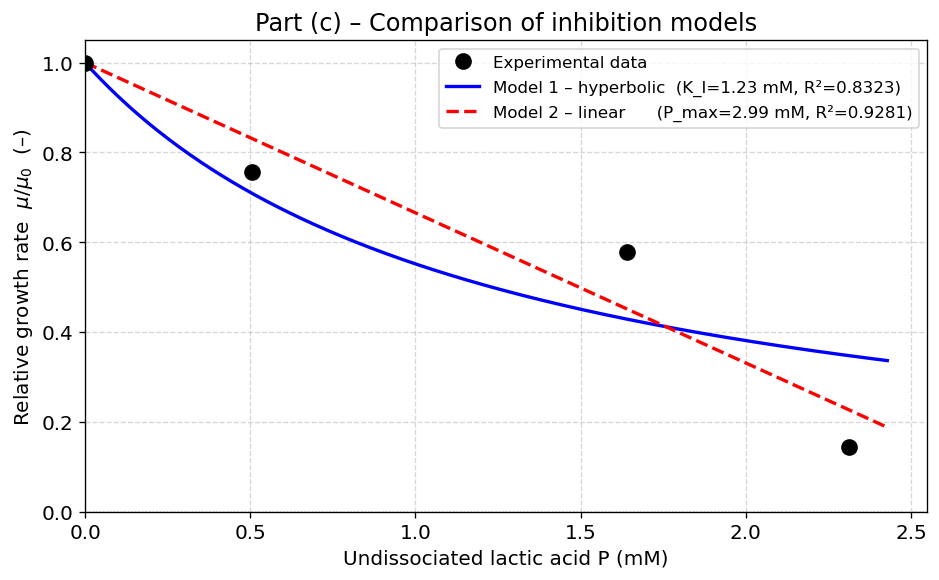


→ The model with the higher R² (lower RMSE) fits the data better.


In [198]:
# Combined plot
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(P_mM, mu_rel, 'ko', markersize=9, zorder=5, label='Experimental data')
ax.plot(P_fit, mu_rel_model1, 'b-',  lw=2,
        label=f'Model 1 – hyperbolic  (K_I={KI_b:.2f} mM, R²={r2_m1:.4f})')
ax.plot(P_fit, mu_rel_model2, 'r--', lw=2,
        label=f'Model 2 – linear      (P_max={P_max_c:.2f} mM, R²={r2_m2:.4f})')

ax.axhline(0, color='k', lw=0.8, linestyle=':')
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.set_xlabel('Undissociated lactic acid P (mM)')
ax.set_ylabel(r'Relative growth rate  $\mu / \mu_0$  (–)')
ax.set_title('Part (c) – Comparison of inhibition models')
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('part_c_model_comparison.png')
plt.show()

print("\n→ The model with the higher R² (lower RMSE) fits the data better.")

## Part (d) – Growth rate vs pH at fixed total lactic acid concentrations

### Strategy
Using the "better model" given in part (c), write µ_rel as a function of pH:
$$P(\text{pH}) = f_{\text{HA}}(\text{pH}) \times \frac{p_{\text{total}}}{M_w} \times 1000$$

with $f_{\text{HA}}(\text{pH}) = \dfrac{1}{1 + 10^{\text{pH} - \text{pK}_a}}$.

We then plot µ_rel vs pH for:
- $p_{\text{total}} = 1$ g/L
- $p_{\text{total}} = 10$ g/L

Growth stops when µ_rel = 0, i.e. when $P = P_{\max}$ (Model 2) or equivalently $\mu \leq 0$.

Best model: Model 2 (linear), P_max = 2.9901 mM
p_total =    1 g/L → growth stops at pH ≈ 4.313
p_total =   10 g/L → growth stops at pH ≈ 5.438


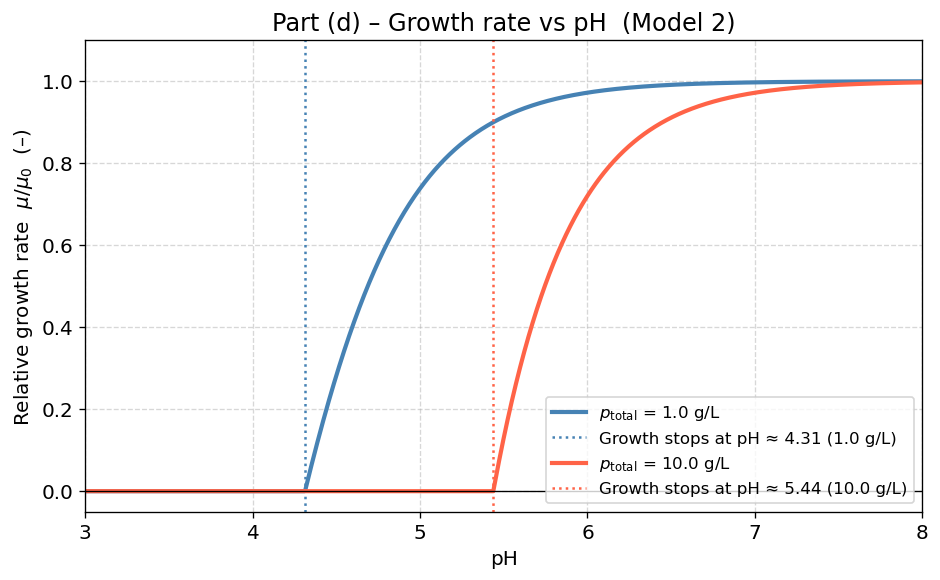

In [199]:
# Select the better model 
if r2_m1 >= r2_m2:
    best_model = 1
    print(f"Best model: Model 1 (hyperbolic), K_I = {KI_b:.4f} mM")
    def mu_rel_of_P(P):
        return 1.0 / (1.0 + P / KI_b)  
else:
    best_model = 2
    print(f"Best model: Model 2 (linear), P_max = {P_max_c:.4f} mM")
    def mu_rel_of_P(P):
        val = 1.0 - P / P_max_c
        return np.maximum(val, 0.0)     

# pH range 
pH_range = np.linspace(3.0, 8.0, 1000)

def f_HA_of_pH(pH_val):
    return 1.0 / (1.0 + 10.0**(pH_val - pKa))

def P_of_pH(pH_val, p_total):
    """Undissociated acid concentration [mM] as a function of pH."""
    return f_HA_of_pH(pH_val) * (p_total / Mw) * 1000.0

# Compute µ_rel vs pH for 1 g/L and 10 g/L 
p_concentrations = [1.0, 10.0]   # g/L
colors = ['steelblue', 'tomato']

fig, ax = plt.subplots(figsize=(8, 5))

pH_stop_list = []

for p_tot, col in zip(p_concentrations, colors):
    P_pH = P_of_pH(pH_range, p_tot)
    mu_rel_pH = mu_rel_of_P(P_pH)

    ax.plot(pH_range, mu_rel_pH, color=col, lw=2.5,
            label=f'$p_{{\\rm total}}$ = {p_tot} g/L')

    # Analytical computation of pH where P = P_max (growth stops)
  
    f_HA_stop = P_max_c * Mw / (p_tot * 1000.0)

    if f_HA_stop < 1.0:  # physically valid solution
        pH_stop = pKa + np.log10(1.0 / f_HA_stop - 1.0)
        pH_stop_list.append(pH_stop)
        ax.axvline(pH_stop, color=col, linestyle=':', lw=1.5,
                   label=f'Growth stops at pH ≈ {pH_stop:.2f} ({p_tot} g/L)')
        print(f"p_total = {p_tot:4.0f} g/L → growth stops at pH ≈ {pH_stop:.3f}")
    else:
        print(f"p_total = {p_tot:4.0f} g/L → growth is always zero in this pH range")
ax.axhline(0, color='k', lw=0.8, linestyle='-')
ax.set_xlabel('pH')
ax.set_ylabel(r'Relative growth rate  $\mu / \mu_0$  (–)')
ax.set_title(f'Part (d) – Growth rate vs pH  (Model {best_model})')
ax.set_xlim(3, 8)
ax.set_ylim(-0.05, 1.1)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('part_d_mu_vs_pH.png')
plt.show()

In [200]:
# Summary of all key results 
print("SUMMARY OF RESULTS – EXERCISE 2")

print(f"\n(a)  f_HA at pH {pH}  = {f_HA:.6f}")
print("     P values (mM):", np.round(P_mM, 4))
print(f"\n(b)  µ_max (Model 1)  = {mu_max_b:.4f} h⁻¹")
print(f"     K_I  (Model 1)  = {KI_b:.4f} mM")
print(f"\n(c)  µ_max (Model 2)  = {mu_max_c:.4f} h⁻¹")
print(f"     P_max (Model 2)  = {P_max_c:.4f} mM")
print(f"\n     Model 1 R² = {r2_m1:.5f},  RMSE = {rmse_m1:.5f} h⁻¹")
print(f"     Model 2 R² = {r2_m2:.5f},  RMSE = {rmse_m2:.5f} h⁻¹")
print(f"\n     → Best model: Model {best_model}")
print(f"\n(d)  Growth stops (pH, p_total):")
for p_tot, pH_stop in zip(p_concentrations, pH_stop_list):
    print(f"       {p_tot} g/L  →  pH ≈ {pH_stop:.3f}")

SUMMARY OF RESULTS – EXERCISE 2

(a)  f_HA at pH 6.3  = 0.003787
     P values (mM): [0.     0.5046 1.6398 2.3125]

(b)  µ_max (Model 1)  = 0.9000 h⁻¹
     K_I  (Model 1)  = 1.2311 mM

(c)  µ_max (Model 2)  = 0.8886 h⁻¹
     P_max (Model 2)  = 2.9901 mM

     Model 1 R² = 0.83230,  RMSE = 0.11519 h⁻¹
     Model 2 R² = 0.92809,  RMSE = 0.07543 h⁻¹

     → Best model: Model 2

(d)  Growth stops (pH, p_total):
       1.0 g/L  →  pH ≈ 4.313
       10.0 g/L  →  pH ≈ 5.438
